# Week 5 Day 3 Lab

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [ ]:
def gd(f, df, x0, delta, iterations):
    x = x0

    for i in range(iterations):
        grad = df(x)

        if grad > 0:
            x -= delta
        elif grad < 0:
            x += delta
        else:
            break 
    return x

### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [6]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
def f(x):
    return x**2 + 4*np.sin(x)
def df(x):
    return 2*x + 4*np.cos(x)
def gd(f, df, x0, delta, iterations):
    x = x0
    for _ in range(iterations):
        grad = df(x)
        if grad > 0:
            x -= delta
        elif grad < 0:
            x += delta
        else:
            break

    return x

%timeit gd(f, df, x0=0, delta=0.001, iterations=100)
%timeit minimize(f, x0=0)



38.2 μs ± 5.18 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
879 μs ± 47 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

In [ ]:
np.random.seed(0)
x = np.linspace(0, 10, 100)
y = 3*x + 2 + np.random.normal(0, 1, len(x))
def sse(params):
    m, b = params
    return np.sum((y - (m*x + b))**2)
%timeit minimize(sse, [0, 0])
%timeit np.polyfit(x, y, 1)
result = minimize(sse, [0, 0])
m1, b1 = result.x
m2, b2 = np.polyfit(x, y, 1)
print("Minimize:")
print("Slope =", m1)
print("Intercept =", b1)
print("\nPolyfit:")
print("Slope =", m2)
print("Intercept =", b2)

### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

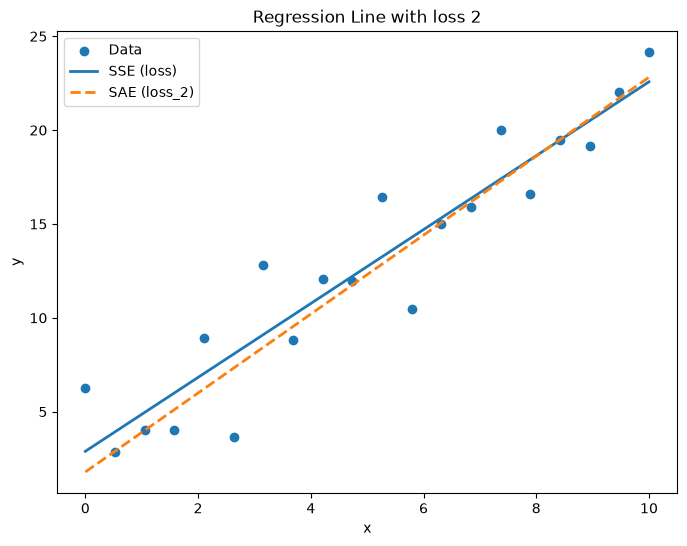

SSE line:
Slope = 1.9684441003190847 Intercept = 2.891050278381666

SAE line:
Slope = 2.102646189918321 Intercept = 1.7907545921600143


In [7]:
np.random.seed(1)
x = np.linspace(0, 10, 20)
y = 2*x + 3 + np.random.normal(0, 2, len(x))
def loss(params):
    m, b = params
    y_pred = m*x + b
    return np.sum((y - y_pred)**2)
def loss2(params):
    m, b = params
    y_pred = m*x + b
    return np.sum(np.abs(y - y_pred))
result1 = minimize(loss, [0, 0])
result2 = minimize(loss2, [0, 0])
m1, b1 = result1.x
m2, b2 = result2.x
plt.figure(figsize=(8,6))
plt.scatter(x, y, label='Data')
plt.plot(x, m1*x + b1, label='SSE (loss)', linewidth=2)
plt.plot(x, m2*x + b2, '--', label='SAE (loss_2)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regression Line with loss 2')
plt.legend()
plt.show()
print("SSE line:")
print("Slope =", m1, "Intercept =", b1)

print("\nSAE line:")
print("Slope =", m2, "Intercept =", b2)